# **Heart Murmur Detection Project**

 Project OverviewThe goal of this project is to automate the detection of Heart Murmurs from audio recordings (PCG). Identifying these murmurs early can help in diagnosing various cardiovascular conditions.

## **Data loading ( pulling data from kaggle )**

In [ ]:
import kagglehub   # Download dataset from kaggle

# Download latest version
path = kagglehub.dataset_download("abdallahaboelkhair/heartbeat-sound")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heartbeat-sound' dataset.
Path to dataset files: /kaggle/input/heartbeat-sound


## **Heartbeat sounds**

Heart sounds are produced from a
specific cardiac event such as closure of
a valve or tensing of a chordae
tendineae.

• S1 result from the closing of the mitral
and tricuspid valves.

• S2 produced by the closure of the aortic
and pulmonic valves.

In medicine we call the ‘lub’
sound "S1" and the ‘dub’ sound
"S2".

You can learn short intro about heart sounds from this video:

https://www.youtube.com/watch?v=dBwr2GZCmQM

## **About data:**

Is challenge published in 2012 to classify the heart sound to some categories from ‘AISTATS’ .
Data has been gathered from two sources (A) and (B).

A) from the general public via the iStethoscope Pro.

B) from a clinic trial in hospitals using the digital stethoscope DigiScope.

Before we work on this nootebook we handle the data folders and conctante both sources(A&B) to be easy to deal with it.

Original Data here: http://www.peterjbentley.com/heartchallenge/

## **Import main libraries**

In [ ]:
# --- DATA ACCESS & FILE MANAGEMENT ---
import os   # fetch our data and manage folder and paths
import glob   # file pattern matching
import fnmatch    # filename filltering


# --- DATA HANDLING & NUMERICAL LOGIC ---
import pandas as pd    # Data manipulation and load data
import numpy as np   # Mathematical operations and applying audio logics
import math    # Core mathmatical calculations


# --- DATA VISUALIZATION ---
import seaborn as sns
import matplotlib.pyplot as plt    # Data visualization


# --- AUDIO PROCESSING & ANALYSIS ---
import librosa    # load audio and extract features like MFCCs
import librosa.display   # visualize audio signals as waves or spectrograms
import IPython.display as ipd    # To play audio files directly


# --- DEEP LEARNING ---
import tensorflow as tf    # core engine for building the AI model (AI Framework)
from tensorflow.keras.utils import to_categorical    # To convert labels into One-Hot encoding
from tensorflow.keras.layers import concatenate    #  Joining audio


from tensorflow.keras.models import Sequential, Model, load_model

from tensorflow.keras.layers import Conv1D, Conv2D, SeparableConv1D, MaxPooling1D, MaxPooling2D
from tensorflow.keras.layers import Input, add, Flatten, Dense, BatchNormalization, Dropout, LSTM, GRU
from tensorflow.keras.layers import GlobalMaxPooling1D, GlobalMaxPooling2D, Activation, LeakyReLU, ReLU

from tensorflow.keras import regularizers
from tensorflow.keras import backend as K
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping


from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,matthews_corrcoef
from sklearn.metrics import cohen_kappa_score,roc_auc_score,confusion_matrix,classification_report

In [ ]:
data_path = "/kaggle/input/heartbeat-sound/Heartbeat_Sound"
print(os.listdir(data_path))

['artifact', 'unlabel', 'extrastole', 'extrahls', 'normal', 'murmur']


In [ ]:
train_data = data_path

unlabel_data = data_path + '/unlabel/'

normal_data = data_path + '/normal/'
murmur_data = data_path + '/murmur/'
artifact_data = data_path + '/artifact/'
extrastole_data = data_path + '/extrastole/'
extrahls_data = data_path + '/extrahls/'

In [ ]:
print("Normal files:", len(os.listdir(normal_data)))         # length of normal training sounds
print("Murmur files:",len(os.listdir(murmur_data)))          # length of murmur training sounds
print("Extrastole files", len(os.listdir(extrastole_data)))  # length of extrastole training sounds
print("Artifact files:",len(os.listdir(artifact_data)))      # length of artifact training sounds
print("Extrahls files:",len(os.listdir(extrahls_data)))      # length of extrahls training sounds

print('TOTAL TRAIN SOUNDS:', len(os.listdir(normal_data))
                              + len(os.listdir(murmur_data))
                              + len(os.listdir(extrastole_data))
                              + len(os.listdir(artifact_data))
                              + len(os.listdir(extrahls_data)))

Normal files: 351
Murmur files: 129
Extrastole files 46
Artifact files: 40
Extrahls files: 19
TOTAL TRAIN SOUNDS: 585


In [ ]:
print("Test Sounds:", len(os.listdir(unlabel_data)))

Test Sounds: 247


## **EDA and Visualization**

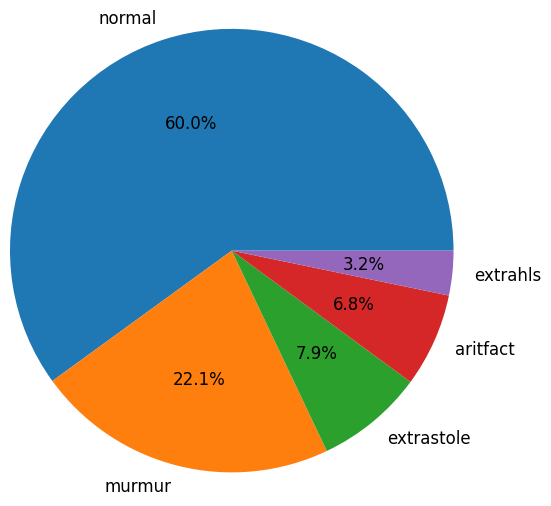

In [ ]:
x = np.array([len(os.listdir(normal_data)),
              len(os.listdir(murmur_data)),
              len(os.listdir(extrastole_data)),
              len(os.listdir(artifact_data)),
              len(os.listdir(extrahls_data))
              ])

labels = ['normal','murmur','extrastole','aritfact','extrahls']
plt.pie(x, labels=labels, autopct = '%.1f%%', radius=1.5, textprops={'fontsize':12})
plt.show()

### To pick a random sound

In [ ]:
# Listen to rondom audio from specific class

def random_sound (audio_class):
    random_sound = np.random.randint(0,len(os.listdir(audio_class)))
    sound = os.listdir(audio_class)[random_sound]
    sound = audio_class+sound
    sound,sample_rate = librosa.load(sound)
    return ipd.Audio(sound,rate=sample_rate),sound

### Waveform

Sound is the pressure of air propagates to our ear. Digital audio file is gotten from a sound sensor that can detects sound waves and converting it to electrical signals.
Specifically, it's telling us about the wave's displacement, and how it changes over time.



X axis, represents time.
Y-axis measures displacement of air molecules.This is where amplitude comes in. It measures how much a molecule is displaced from its resting position.  

In [ ]:
# show waveform of audio from dataset
# X axis, represents time.
# Y-axis measures displacement of air molecules.
# This is where amplitude comes in. It measures how much a molecule is displaced from its resting position.
def show_audio_waveform(audio_sample):
    plt.figure(figsize=(20,5))
    librosa.display.waveshow(audio_sample, sr=22050)
    plt.title("Sound")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.show()

### Spectrum

A sound spectrum is a representation of a sound – usually a short sample of a sound – in terms of the amount of vibration at each individual frequency. It is usually presented as a graph of either power or pressure as a function of frequency. The power or pressure is usually measured in decibels and the frequency is measured in vibrations per second (or hertz, abbreviation Hz) or thousands of vibrations per second (kilohertz, abbreviation kHz).

The spectrum expresses the frequency composition of the sound and is obtained by analyzing the sound. A sound spectrum is usually represented in a coordinate plane where the frequency f is plotted along the axis of abscissas and the amplitude A, or intensity, of a harmonic component with a given frequency is plotted along the axis of ordinates.

In [ ]:
# show spectrum of audio from dataset
def show_audio_spectrum(audio_sample):
    sample_rate = 22050
    fft_normal = np.fft.fft(audio_sample)
    magnitude_normal = np.abs(fft_normal)
    freq_normal = np.linspace(0,sample_rate, len(magnitude_normal))
    half_freq = freq_normal[:int(len(freq_normal)/2)]
    half_magnitude = magnitude_normal[:int(len(freq_normal)/2)]

    plt.figure(figsize=(12,8))
    plt.plot(half_freq,half_magnitude)
    plt.title("Spectrum")
    plt.xlabel("Frequency")
    plt.ylabel("Magnitude")
    plt.show()

### Spectogram

For us, as human, we sense a sound not only on a particular time by its intensity, but also by its pitch. The pitch is the frequency of the sound - higher pitch corresponding to higher frequency and vice versa. So, to have a representation which is closer to our brain, we can add another dimension - the frequency - to our representation, which is the Spectrogram.

A spectrogram is a visual representation of the spectrum of frequencies of a signal as it varies with time. When applied to an audio signal, spectrograms are sometimes called sonographs, voiceprints, or voicegrams.

Spectrograms are used extensively in the fields of music, linguistics, sonar, radar, speech processing,seismology, and others. Spectrograms of audio can be used to identify spoken words phonetically, and to analyse the various calls of animals.it can be generated by an optical spectrometer, a bank of band-pass filters, by Fourier transform or by a wavelet transform.

In [ ]:
# show spectogram of audio from dataset
# the output is an image that represents a sound.
# X-axis is for time, y-axis is for frequency and the color is for intensity
def show_spectrogram (audio_sample):
    # STFT -> spectrogram
    hop_length = 512 # in num. of samples
    n_fft = 2048 # window in num. of samples
    sample_rate = 22050

    # calculate duration hop length and window in seconds
    hop_length_duration = float(hop_length)/sample_rate
    n_fft_duration = float(n_fft)/sample_rate

    print("STFT hop length duration is: {}s".format(hop_length_duration))
    print("STFT window duration is: {}s".format(n_fft_duration))

    # perform stft
    stft_normal = librosa.stft(audio_sample, n_fft=n_fft, hop_length=hop_length)

    # calculate abs values on complex numbers to get magnitude
    spectrogram = np.abs(stft_normal)
    log_spectrogram = librosa.amplitude_to_db(spectrogram)

    # display spectrogram
    plt.figure(figsize=(15,10))
    librosa.display.specshow(log_spectrogram, sr=sample_rate, hop_length=hop_length)
    plt.xlabel("Time")
    plt.ylabel("Frequency")
    plt.colorbar()
    #plt.set_cmap("YlOrBr")
    plt.title("Spectrogram")

### MFCCs

We can’t take the raw audio signal as input to our model because there will be a lot of noise in the audio signal. It is observed that extracting features from the audio signal and using it as input to the base model will produce much better performance than directly considering raw audio signal as input. MFCC is the widely used technique for extracting the features from the audio signal.

in sound processing, the mel-frequency cepstrum (MFC) is a representation of the short-term power spectrum of a sound, based on a linear cosine transform of a log power spectrum on a nonlinear mel scale of frequency.

Mel-frequency cepstral coefficients (MFCCs) are coefficients that collectively make up an MFC. They are derived from a type of cepstral representation of the audio clip (a nonlinear "spectrum-of-a-spectrum"). The difference between the cepstrum and the mel-frequency cepstrum is that in the MFC, the frequency bands are equally spaced on the mel scale, which approximates the human auditory system's response more closely than the linearly-spaced frequency bands used in the normal spectrum. This frequency warping can allow for better representation of sound, for example, in audio compression.

**MFCCs are commonly derived as follows:**

1- Take the Fourier transform of (a windowed excerpt of) a signal.

2- Map the powers of the spectrum obtained above onto the mel scale, using triangular overlapping windows or alternatively, cosine overlapping windows.

3- Take the logs of the powers at each of the mel frequencies.

4- Take the discrete cosine transform of the list of mel log powers, as if it were a signal.

5- The MFCCs are the amplitudes of the resulting spectrum.

In [ ]:
# MFCCs
# extract 52 MFCCs
def show_mfcc_features(audio_sample):
    hop_length = 512
    n_fft = 2048
    sample_rate = 22050

    MFCCs = librosa.feature.mfcc(
        y=audio_sample,
        sr=sample_rate,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mfcc=52   # 52 features
    )

    plt.figure(figsize=(15,10))
    librosa.display.specshow(MFCCs, sr=sample_rate, hop_length=hop_length)
    plt.xlabel("Time")
    plt.ylabel("MFCC coefficients")
    plt.colorbar()
    plt.title("MFCCs")
    plt.show()


##  Dataset Classes

### *1. Normal*

Most normal heart rates at rest
will be between about 60 and
100 beats (‘lub dub’s) per
minute.

In [ ]:
normal_audio, normal_sample = random_sound(normal_data)
normal_audio

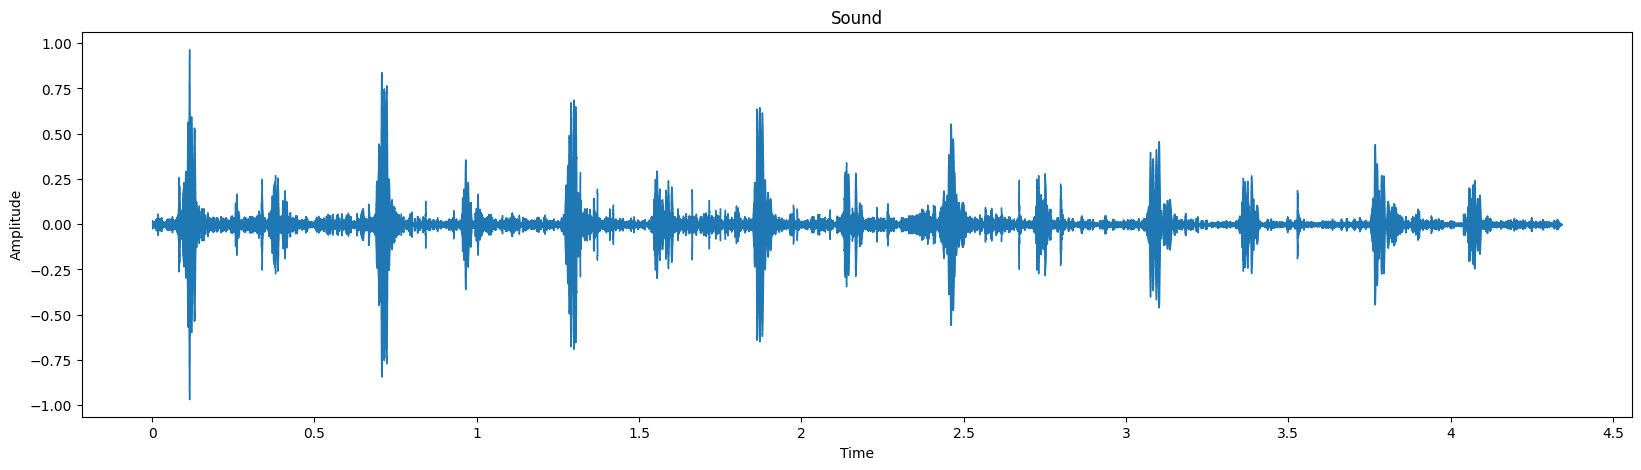

In [ ]:
show_audio_waveform(normal_sample)

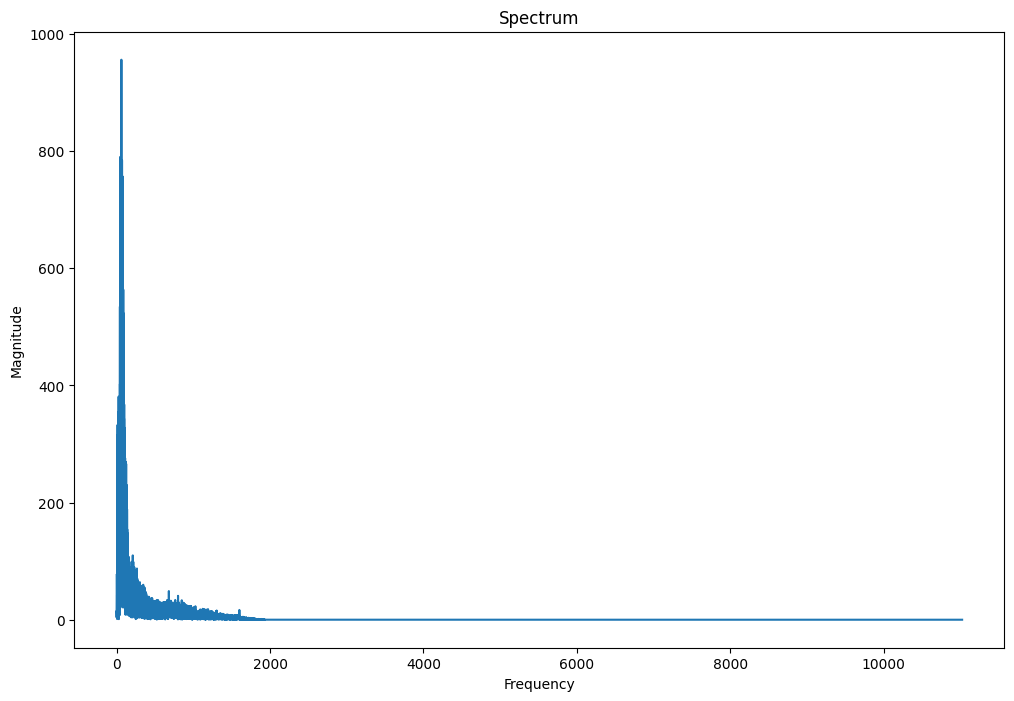

In [ ]:
show_audio_spectrum(normal_sample)

STFT hop length duration is: 0.023219954648526078s
STFT window duration is: 0.09287981859410431s


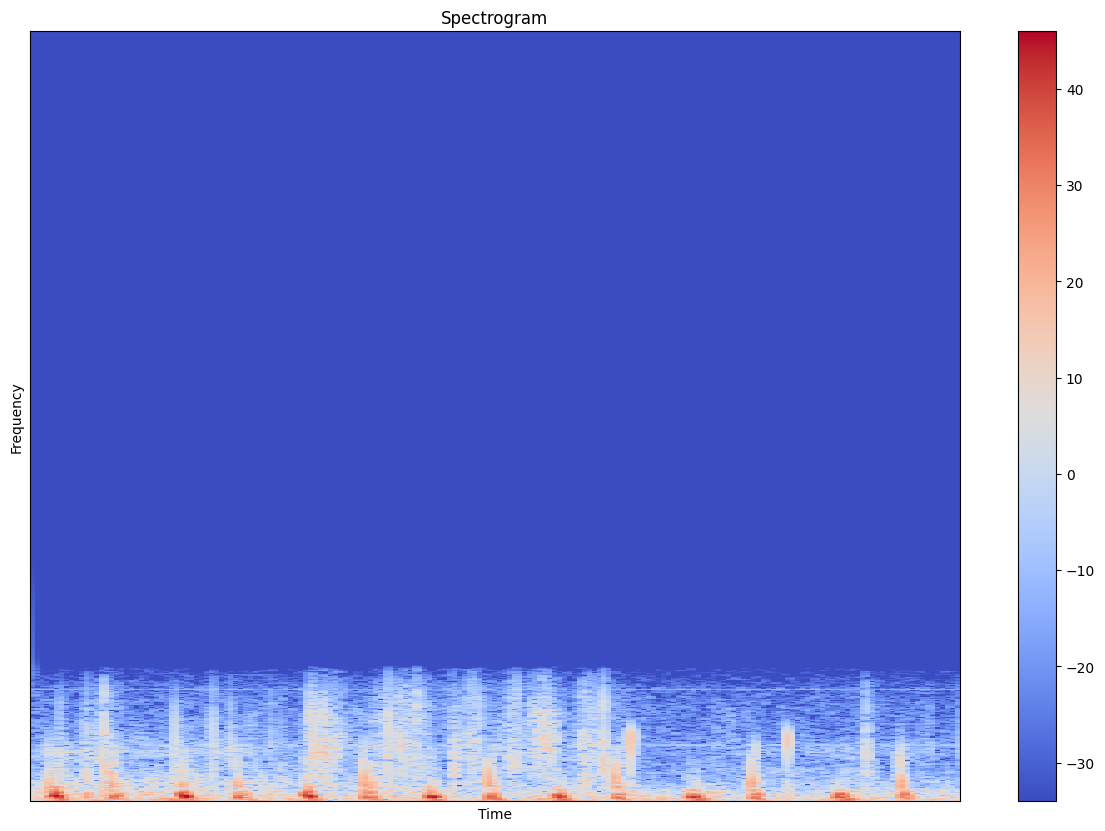

In [ ]:
show_spectrogram(normal_sample)

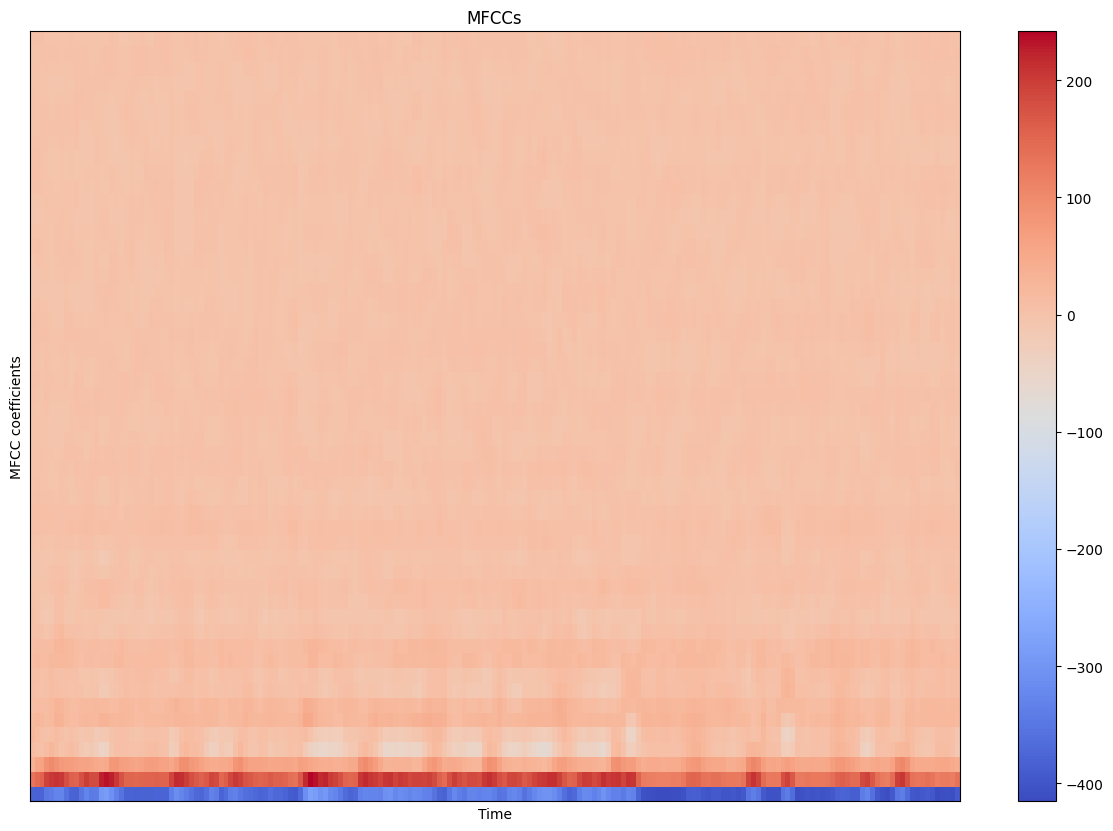

In [ ]:
show_mfcc_features(normal_sample)

### *2. Murmur sound*

Heart murmurs sound as though there
is a “whooshing, roaring, rumbling, or
turbulent fluid” noise in one of two
temporal locations: (1) between “lub”
and “dub”, or (2) between “dub” and
“lub”. They can be a symptom of many
heart disorders, some serious.

In [ ]:
murmur_audio,murmur_sample = random_sound(murmur_data)
murmur_audio

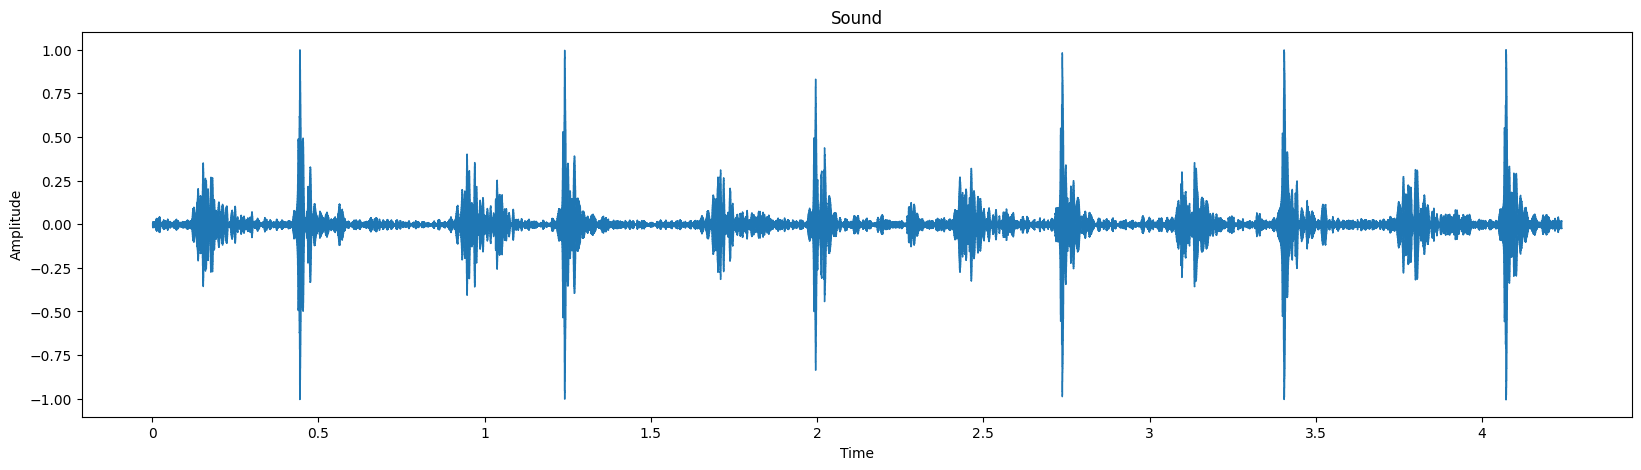

In [ ]:
show_audio_waveform(murmur_sample)

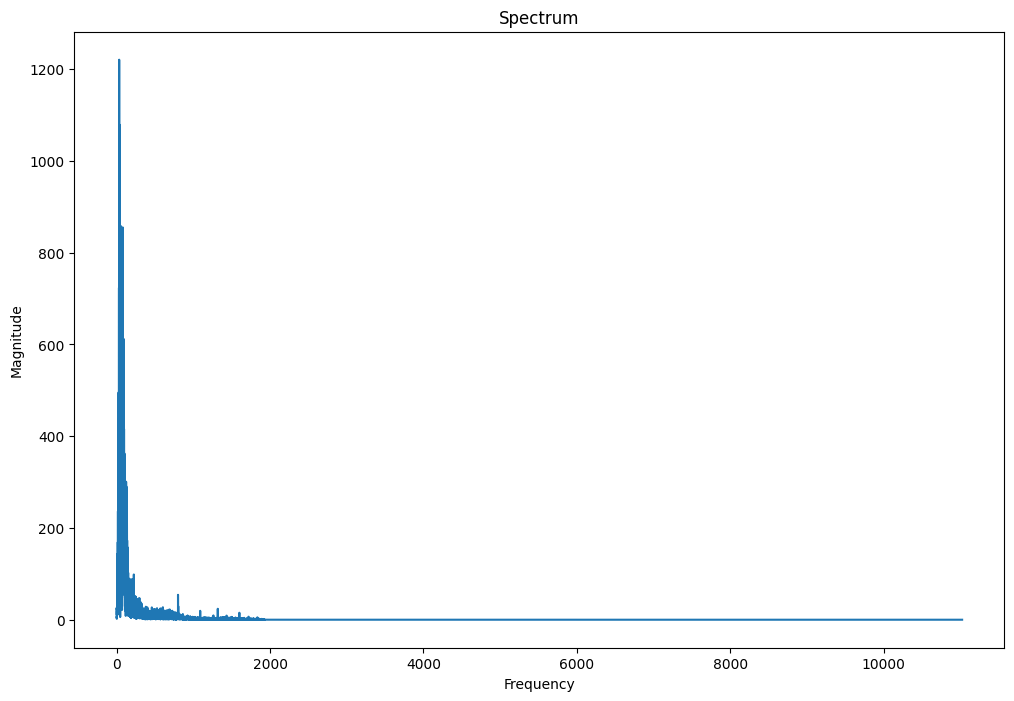

In [ ]:
show_audio_spectrum(murmur_sample)

STFT hop length duration is: 0.023219954648526078s
STFT window duration is: 0.09287981859410431s


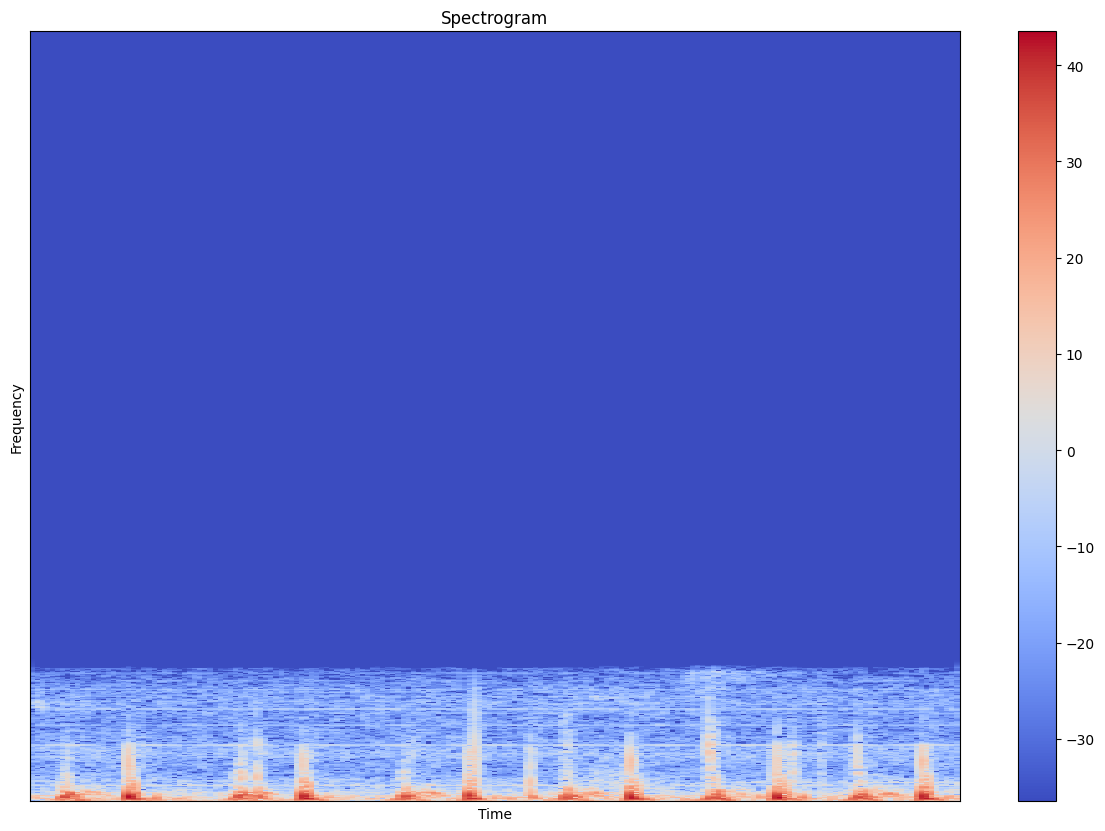

In [ ]:
show_spectrogram(murmur_sample)

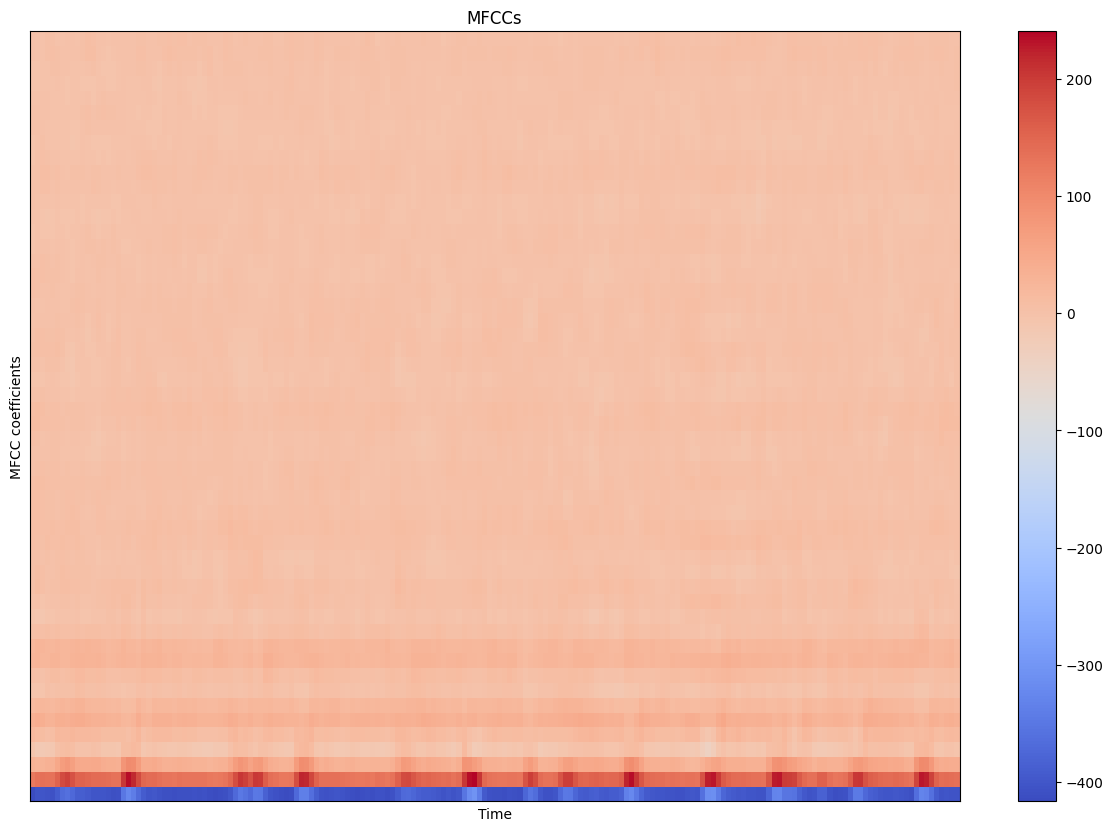

In [ ]:
show_mfcc_features(murmur_sample)

### *3. Extrastole sound*

• Extrasystole sounds may appear occasionally and can be
identified because there is a heart sound that is out of rhythm
involving extra or skipped heartbeats, e.g. a “lub-lub dub” or a
“lub dub-dub”.

In [ ]:
extrastole_audio, extrastole_sample  = random_sound(extrastole_data)
extrastole_audio

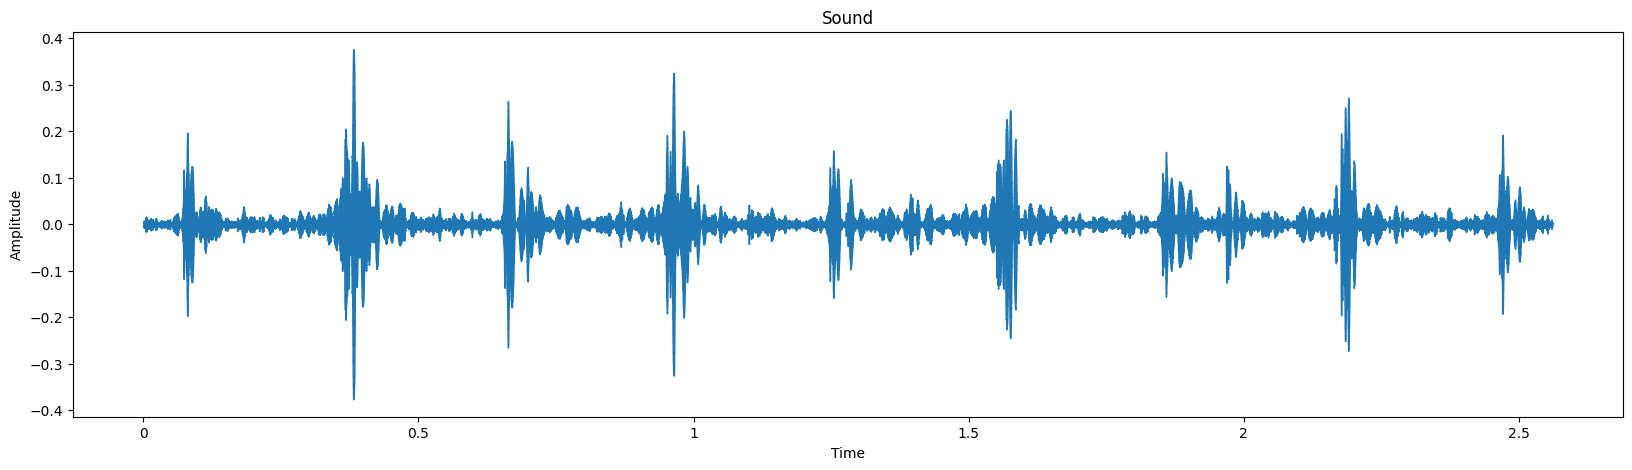

In [ ]:
show_audio_waveform(extrastole_sample)

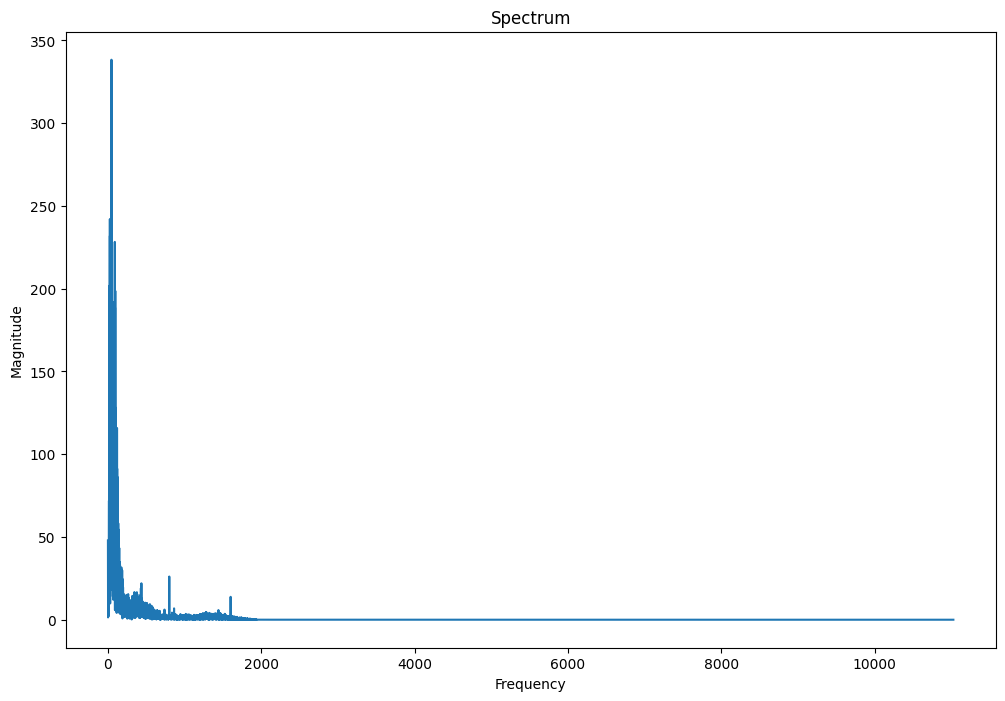

In [ ]:
show_audio_spectrum(extrastole_sample)

STFT hop length duration is: 0.023219954648526078s
STFT window duration is: 0.09287981859410431s


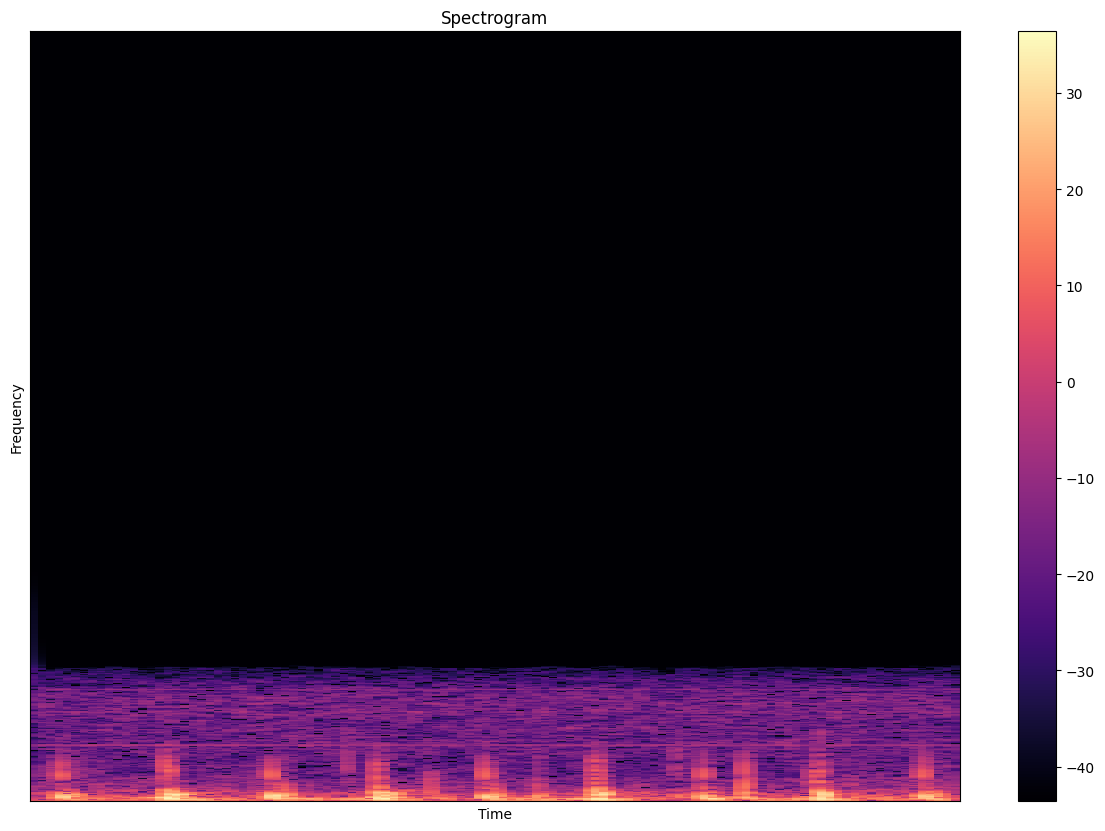

In [ ]:
show_spectrogram(extrastole_sample)

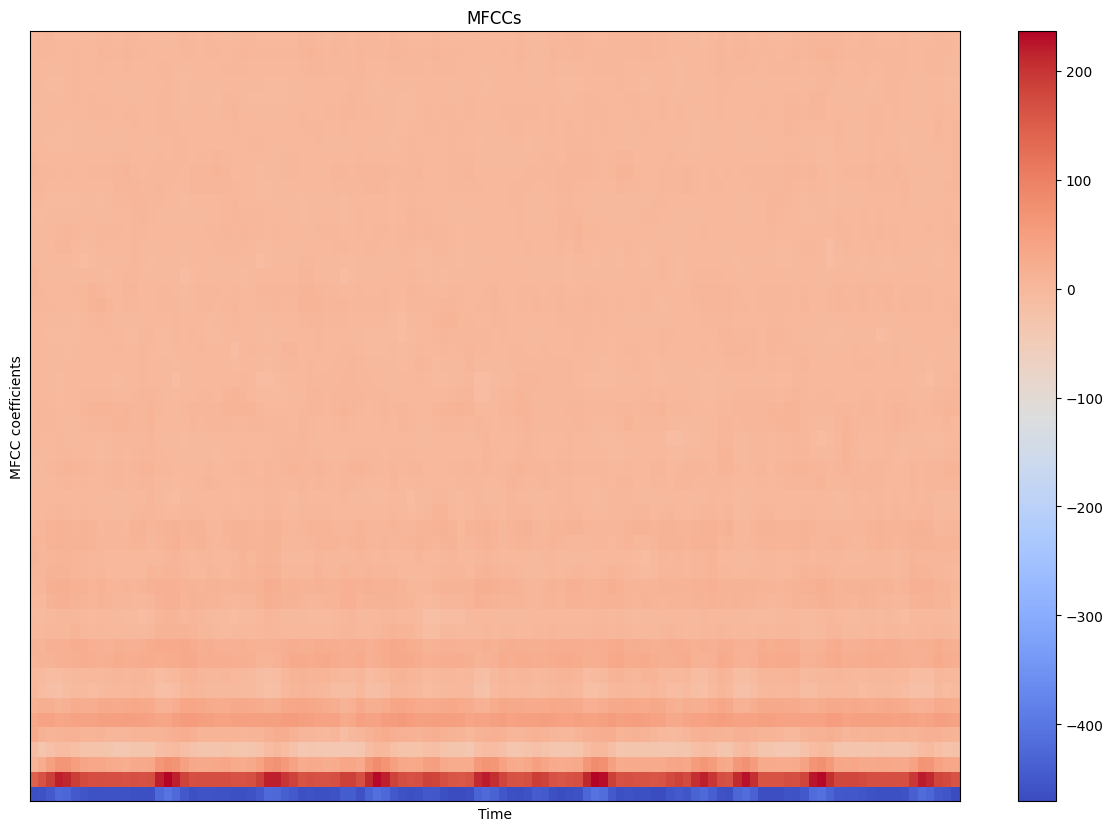

In [ ]:
show_mfcc_features(extrastole_sample)

### *4. Artifact sound*

• In the Artifact category there are a wide range of different
sounds, including feedback squeals and echoes, speech, music
and noise.

In [ ]:
artifact_audio, artifact_sample  = random_sound(artifact_data)
artifact_audio

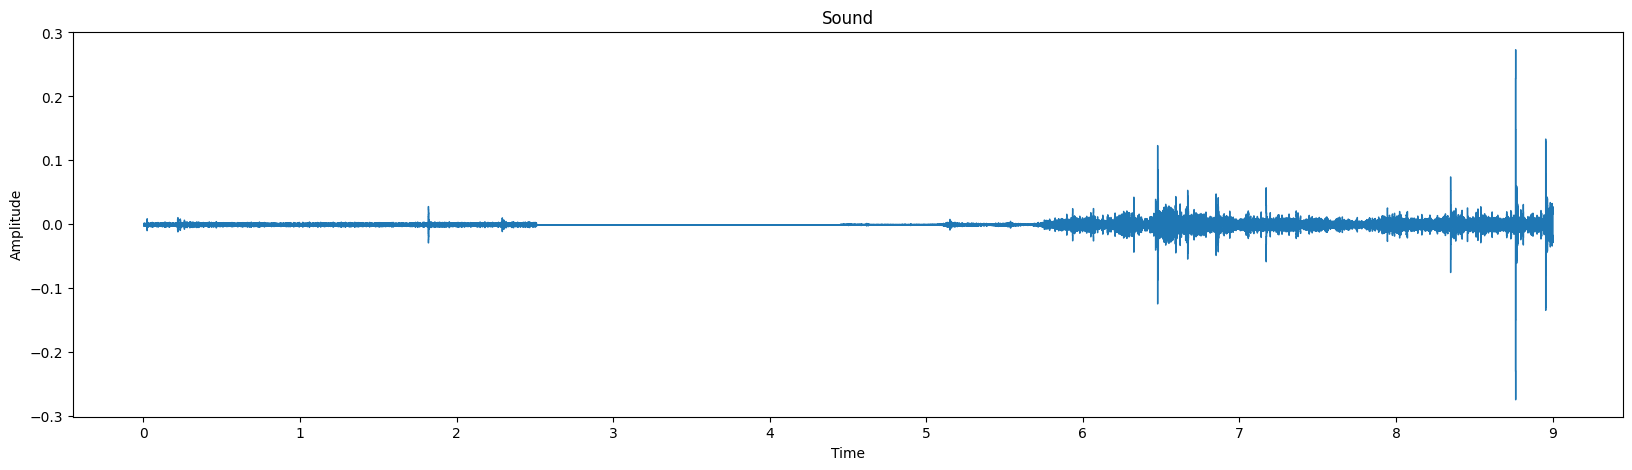

In [ ]:
show_audio_waveform(artifact_sample)

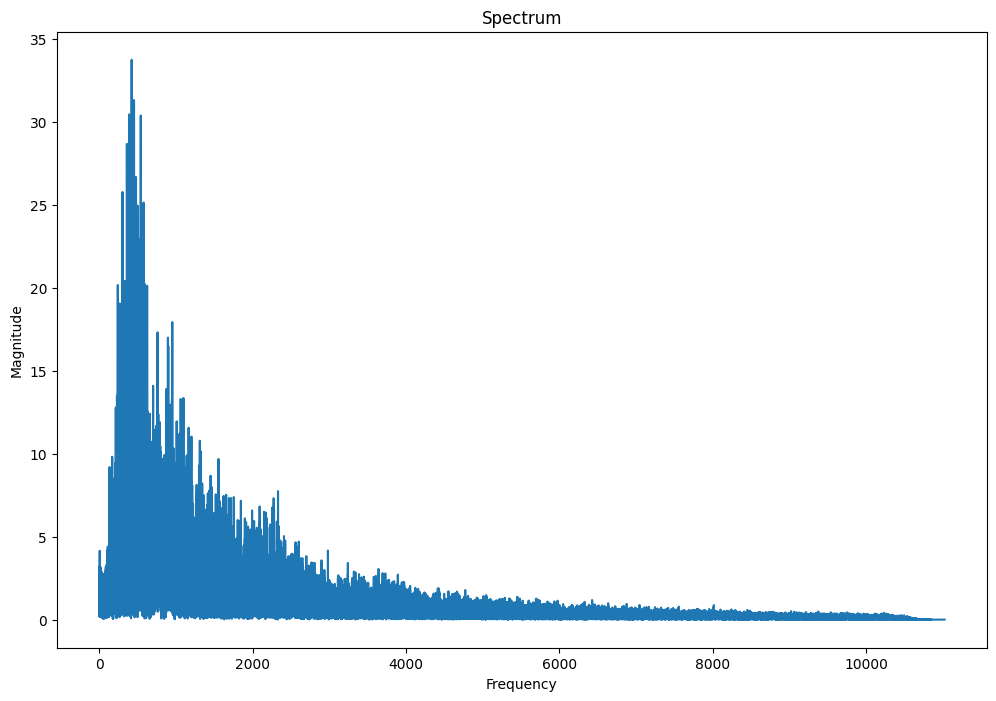

In [ ]:
show_audio_spectrum(artifact_sample)

STFT hop length duration is: 0.023219954648526078s
STFT window duration is: 0.09287981859410431s


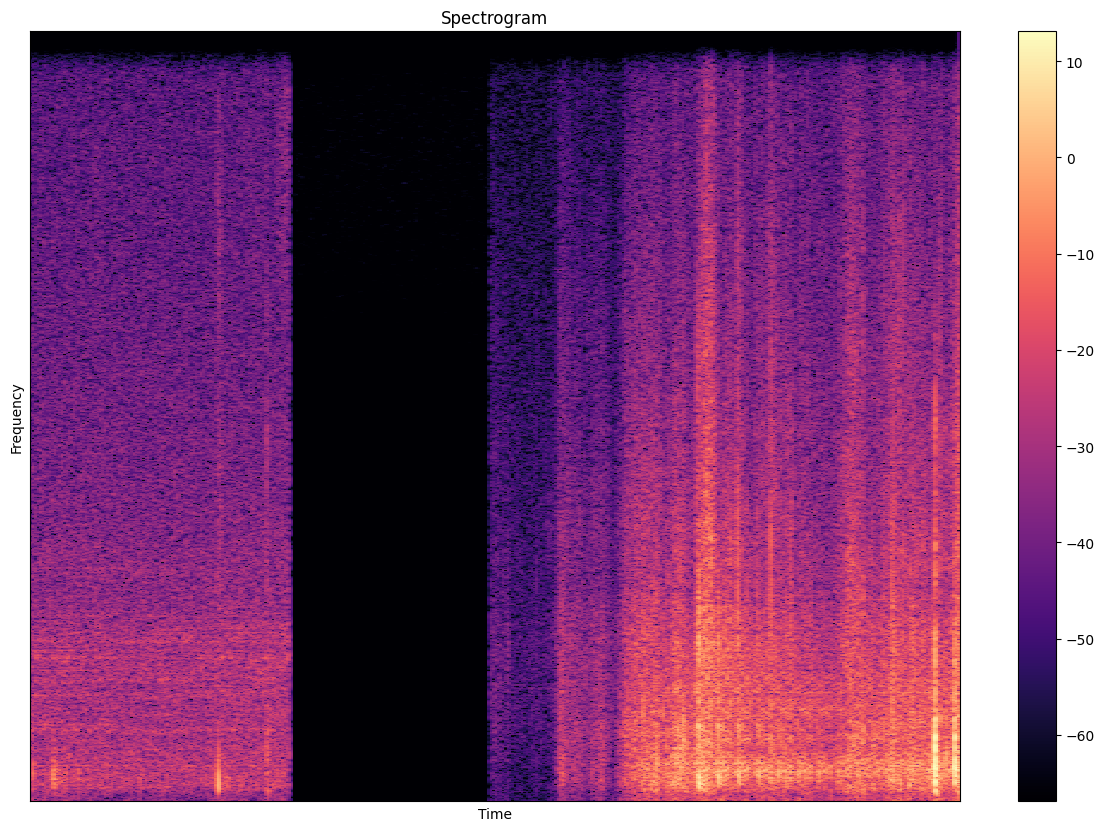

In [ ]:
show_spectrogram(artifact_sample)

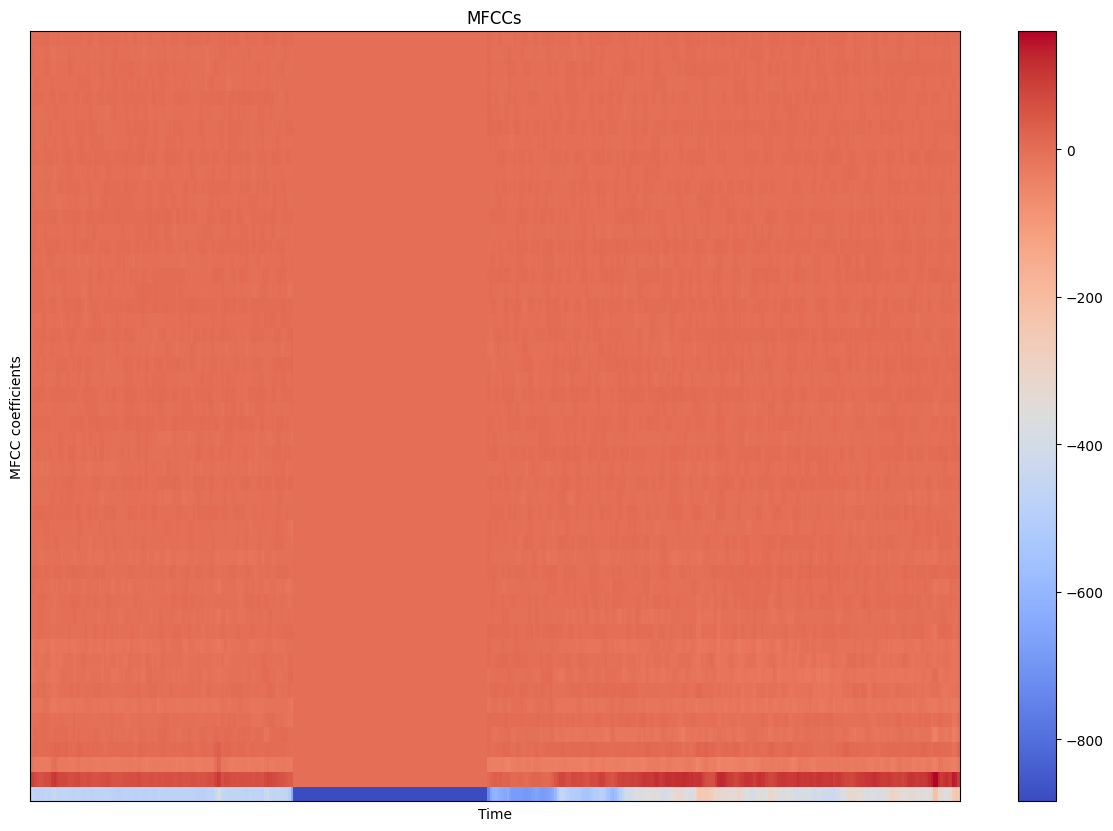

In [ ]:
show_mfcc_features(artifact_sample)

### *5. Extrahls sound*

Extra heart sounds can be identified because there is an
additional sound, e.g. a “lub-lub dub” or a “lub dub-dub”.

In [ ]:
extrahls_audio, extrahls_sample  = random_sound(extrahls_data)
extrahls_audio

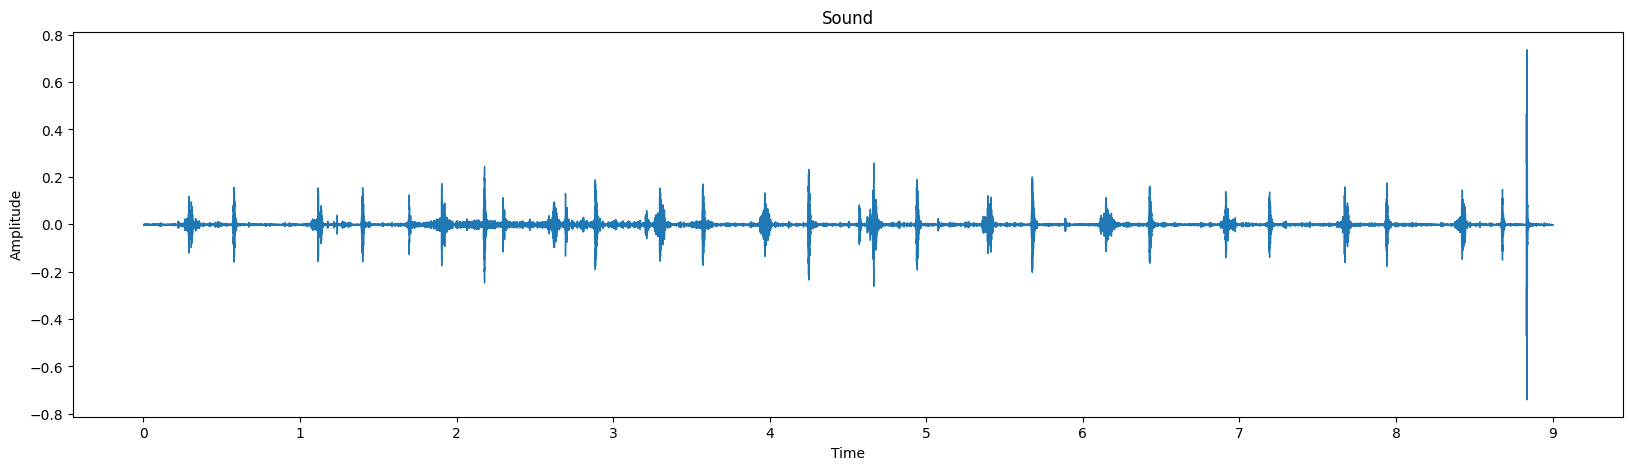

In [ ]:
show_audio_waveform(extrahls_sample)

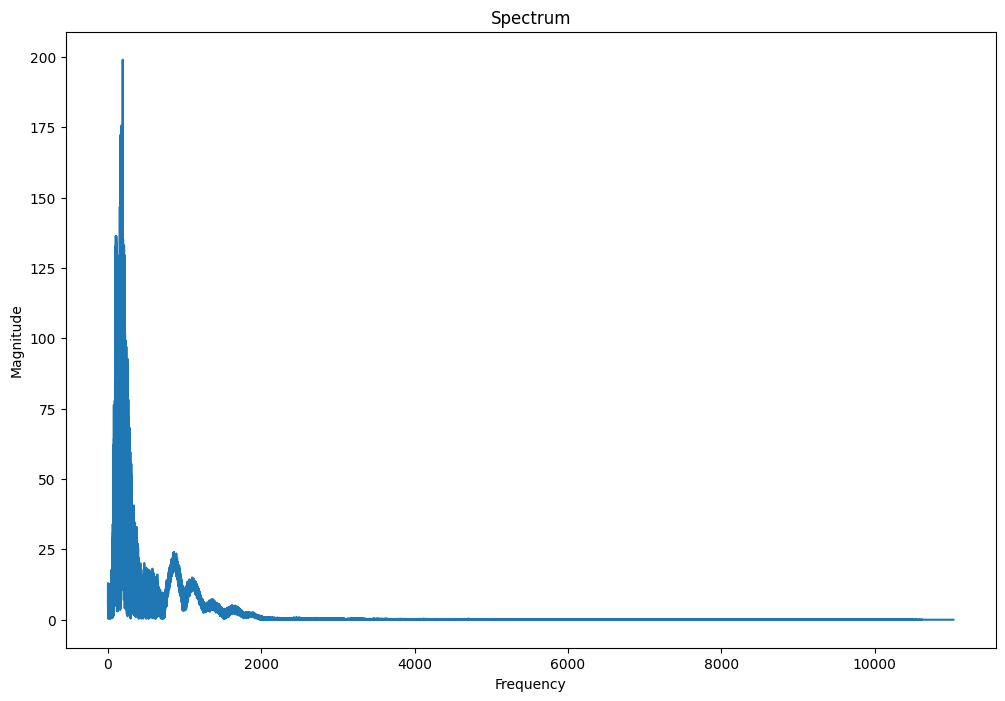

In [ ]:
show_audio_spectrum(extrahls_sample)

STFT hop length duration is: 0.023219954648526078s
STFT window duration is: 0.09287981859410431s


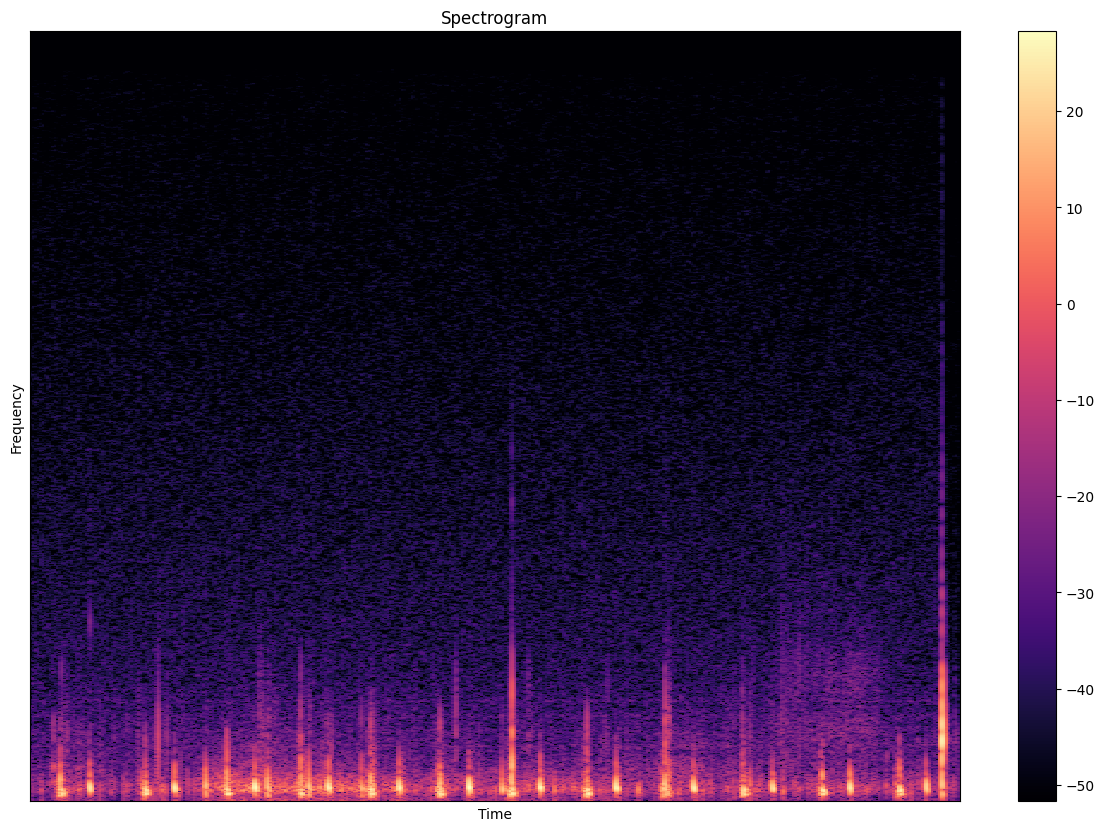

In [ ]:
show_spectrogram(extrahls_sample)

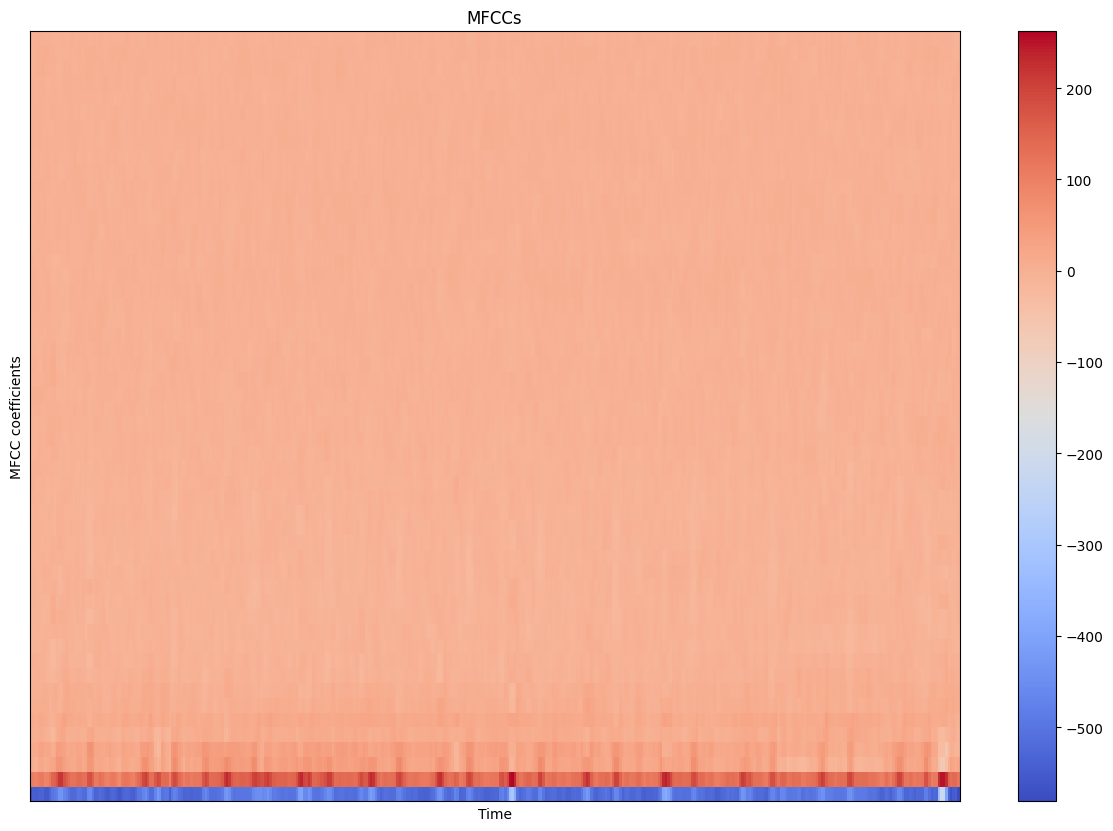

In [ ]:
show_mfcc_features(extrahls_sample)

# Data Preprocessing

#### Making necessary functions

In [ ]:
def add_noise(data,x):
    noise = np.random.randn(len(data))
    data_noise = data + x * noise
    return data_noise

def shift(data,x):
    return np.roll(data, x)

def stretch(data, rate):
    return librosa.effects.time_stretch(y=data, rate=rate)

def pitch_shift(data, rate, sr=22050):
    return librosa.effects.pitch_shift(y=data, sr=sr, n_steps=rate)


```
        Extract MFCC feature from the Sound data from the audio data.
        Augmentation of sound data by adding Noise, streaching and shifting.
        52 features are extracted from each audio data and used to train the model.

        Args:
            dir_: Input directory to the Sound input file.

        Returns:
            data: list of features extracted from the sound file.
```

In [ ]:
def load_file_data(folder, file_names, duration=10, sr=22050):
    input_length = sr * duration
    features = 52
    data = []

    for file_name in file_names:
        try:
            sound_file = folder + file_name
            X, sr = librosa.load(sound_file, sr=sr, duration=duration)
            dur = librosa.get_duration(y=X, sr=sr)

            # pad audio file to same duration
            if round(dur) < duration:
                print("fixing audio length:", file_name)
                X = librosa.util.fix_length(data=X, size=input_length)

            # original MFCC
            mfccs = np.mean(librosa.feature.mfcc(
                y=X, sr=sr, n_mfcc=features).T, axis=0)
            data.append(mfccs.reshape([-1, 1]))

            # stretch 0.8
            stretch_1 = stretch(X, 0.8)
            mfcc_1 = np.mean(librosa.feature.mfcc(
                y=stretch_1, sr=sr, n_mfcc=features).T, axis=0)
            data.append(mfcc_1.reshape([-1, 1]))

            # stretch 1.2
            stretch_2 = stretch(X, 1.2)
            mfcc_2 = np.mean(librosa.feature.mfcc(
                y=stretch_2, sr=sr, n_mfcc=features).T, axis=0)
            data.append(mfcc_2.reshape([-1, 1]))

        except Exception as e:
            print("Error encountered while parsing file:", file_name, "=>", e)

    return data


## Encoding

In [ ]:
# simple encoding of categories, convert to only 3 types:
# Normal (Include extrahls and extrastole)
# Murmur
# Artifact

# Map label text to integer
CLASSES = ['artifact','murmur','normal']
NB_CLASSES=len(CLASSES)

# Map integer value to text labels
label_to_int = {k:v for v,k in enumerate(CLASSES)}
print (label_to_int)
print (" ")
int_to_label = {v:k for k,v in label_to_int.items()}
print(int_to_label)

{'artifact': 0, 'murmur': 1, 'normal': 2}
 
{0: 'artifact', 1: 'murmur', 2: 'normal'}


## Data Standardization and Feature Extraction

In [ ]:
# 22 KHz
SAMPLE_RATE = 22050
# 10 seconds
MAX_SOUND_CLIP_DURATION=10

artifact_files = fnmatch.filter(os.listdir(artifact_data), 'artifact*.wav')
artifact_sounds = load_file_data (folder=artifact_data, file_names = artifact_files, duration=MAX_SOUND_CLIP_DURATION)
artifact_labels = [0 for items in artifact_sounds]

normal_files = fnmatch.filter(os.listdir(normal_data), 'normal*.wav')
normal_sounds = load_file_data(folder=normal_data,file_names=normal_files, duration=MAX_SOUND_CLIP_DURATION)
normal_labels = [2 for items in normal_sounds]

extrahls_files = fnmatch.filter(os.listdir(extrahls_data), 'extrahls*.wav')
extrahls_sounds = load_file_data(folder=extrahls_data,file_names=extrahls_files, duration=MAX_SOUND_CLIP_DURATION)
extrahls_labels = [2 for items in extrahls_sounds]

murmur_files = fnmatch.filter(os.listdir(murmur_data), 'murmur*.wav')
murmur_sounds = load_file_data(folder=murmur_data,file_names=murmur_files, duration=MAX_SOUND_CLIP_DURATION)
murmur_labels = [1 for items in murmur_sounds]


extrastole_files = fnmatch.filter(os.listdir(extrastole_data), 'extrastole*.wav')
extrastole_sounds = load_file_data(folder=extrastole_data,file_names=extrastole_files, duration=MAX_SOUND_CLIP_DURATION)
extrastole_labels = [2 for items in extrastole_sounds]

print ("Loading Done")


fixing audio length: artifact__201106131834.wav
fixing audio length: artifact__201106101955.wav
fixing audio length: artifact__201106220340.wav
fixing audio length: artifact__201105190800.wav
fixing audio length: artifact__201106040722.wav
fixing audio length: artifact__201106070949.wav
fixing audio length: artifact__201106221254.wav
fixing audio length: artifact__201106010602.wav
fixing audio length: artifact__201106021541.wav
fixing audio length: artifact__201106010559.wav
fixing audio length: artifact__201105061143.wav
fixing audio length: artifact__201106110909.wav
fixing audio length: artifact__201106161219.wav
fixing audio length: artifact__201105040918.wav
fixing audio length: artifact__201106211041.wav
fixing audio length: artifact__201106211430.wav
fixing audio length: artifact__201105280851.wav
fixing audio length: artifact__201105051017.wav
fixing audio length: artifact__201106131835.wav
fixing audio length: artifact__201106050353.wav
fixing audio length: artifact__201106141

In [ ]:
print("\nClass-wise sample count (after loading / augmentation if applied):")
print(f"Artifact (label 0):    {len(artifact_labels)}")
print(f"Murmur   (label 1):    {len(murmur_labels)}")
print(f"Normal   (label 2):    {len(normal_labels)}")
print(f"Extrahls (label 2):    {len(extrahls_labels)}")
print(f"Extrastole (label 2):  {len(extrastole_labels)}")

total_samples = (
    len(artifact_labels) +
    len(murmur_labels) +
    len(normal_labels) +
    len(extrahls_labels) +
    len(extrastole_labels)
)

print(f"\nTotal samples: {total_samples}")



Class-wise sample count (after loading / augmentation if applied):
Artifact (label 0):    120
Murmur   (label 1):    387
Normal   (label 2):    1053
Extrahls (label 2):    57
Extrastole (label 2):  138

Total samples: 1755


In [ ]:
# unlabel_datala files
Bunlabelledtest_files = fnmatch.filter(os.listdir(unlabel_data), 'Bunlabelledtest*.wav')
Bunlabelledtest_sounds = load_file_data(folder=unlabel_data,file_names=Bunlabelledtest_files, duration=MAX_SOUND_CLIP_DURATION)
Bunlabelledtest_labels = [-1 for items in Bunlabelledtest_sounds]

Aunlabelledtest_files = fnmatch.filter(os.listdir(unlabel_data), 'Aunlabelledtest*.wav')
Aunlabelledtest_sounds = load_file_data(folder=unlabel_data,file_names=Aunlabelledtest_files, duration=MAX_SOUND_CLIP_DURATION)
Aunlabelledtest_labels = [-1 for items in Aunlabelledtest_sounds]


print ("Loading of unlabel data done")


fixing audio length: Bunlabelledtest__231_1308748318393_C.wav
fixing audio length: Bunlabelledtest__152_1306779561195_C.wav
fixing audio length: Bunlabelledtest__235_1308749032454_C1.wav
fixing audio length: Bunlabelledtest__107_1305654946865_B.wav
fixing audio length: Bunlabelledtest__148_1306768801551_D.wav
fixing audio length: Bunlabelledtest__171_1307971016233_F.wav
fixing audio length: Bunlabelledtest__169_1307970398039_C1.wav
fixing audio length: Bunlabelledtest__148_1306768801551_A.wav
fixing audio length: Bunlabelledtest__179_1307990076841_D1.wav
fixing audio length: Bunlabelledtest__159_1307018640315_C.wav
fixing audio length: Bunlabelledtest__300_1311772096120_D.wav
fixing audio length: Bunlabelledtest__151_1306779785624_A1.wav
fixing audio length: Bunlabelledtest__181_1308052613891_C.wav
fixing audio length: Bunlabelledtest__174_1307987737137_C.wav
fixing audio length: Bunlabelledtest__286_1311170606028_B.wav
fixing audio length: Bunlabelledtest__175_1307987962616_C.wav
fixi

In [ ]:
print("\nUnlabelled test data summary:")

print(f"B-unlabelled test samples : {len(Bunlabelledtest_sounds)}")
print(f"A-unlabelled test samples : {len(Aunlabelledtest_sounds)}")

print("\nAssigned labels check (should be -1):")
print(f"B-unlabelled unique labels : {set(Bunlabelledtest_labels)}")
print(f"A-unlabelled unique labels : {set(Aunlabelledtest_labels)}")

print("\nTotal unlabelled test samples:")
print(len(Bunlabelledtest_sounds) + len(Aunlabelledtest_sounds))



Unlabelled test data summary:
B-unlabelled test samples : 585
A-unlabelled test samples : 156

Assigned labels check (should be -1):
B-unlabelled unique labels : {-1}
A-unlabelled unique labels : {-1}

Total unlabelled test samples:
741


## Concatenation

In [ ]:
#combine set-a and set-b
# sound files
x_data = np.concatenate((artifact_sounds, normal_sounds,extrahls_sounds,murmur_sounds,extrastole_sounds))
# contains labels
y_data = np.concatenate((artifact_labels, normal_labels,extrahls_labels,murmur_labels,extrastole_labels))

test_x = np.concatenate((Aunlabelledtest_sounds,Bunlabelledtest_sounds))
test_y = np.concatenate((Aunlabelledtest_labels,Bunlabelledtest_labels))

print ("combined training data record: ",len(y_data), len(test_y))

combined training data record:  1755 741


## Data Split


In [ ]:
# shuffle - whether or not to shuffle the data before splitting. If shuffle=False then stratify must be None.

# split data into Train, Validation and Test
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, train_size=0.8, random_state=42, shuffle=True)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, train_size=0.9, random_state=42, shuffle=True)

# One-Hot encoding for classes
y_train = np.array(tf.keras.utils.to_categorical(y_train, len(CLASSES)))
y_test = np.array(tf.keras.utils.to_categorical(y_test, len(CLASSES)))
y_val = np.array(tf.keras.utils.to_categorical(y_val, len(CLASSES)))
test_y=np.array(tf.keras.utils.to_categorical(test_y, len(CLASSES)))

## Correct Imbalnced Data

In [ ]:
# class weight
TRAIN_IMG_COUNT = 578
COUNT_0 = 40  #artifact
COUNT_1 = 129 #murmur
COUNT_2 = 409 #normal
weight_for_0 = TRAIN_IMG_COUNT / (3 * COUNT_0)
weight_for_1 = TRAIN_IMG_COUNT / (3 * COUNT_1)
weight_for_2 = TRAIN_IMG_COUNT / (3 * COUNT_2)
class_weight = {0: weight_for_0, 1: weight_for_1, 2: weight_for_2}
class_weight

{0: 4.816666666666666, 1: 1.4935400516795865, 2: 0.4710676446617767}

# LSTM Model

In [ ]:
x_train_lstm = x_train
x_val_lstm = x_test
x_test_lstm = x_val

y_train_lstm = y_train
y_val_lstm = y_test
y_test_lstm = y_val

## Build Model

In [ ]:
lstm_model = Sequential([
    tf.keras.layers.Input(shape=(52, 1)),

    # feature extraction
    Conv1D(2048, kernel_size=5, strides=1, padding='same', activation='relu'),
    MaxPooling1D(pool_size=2, strides=2, padding='same'),
    BatchNormalization(),

    Conv1D(1024, kernel_size=5, strides=1, padding='same', activation='relu'),
    MaxPooling1D(pool_size=2, strides=2, padding='same'),
    BatchNormalization(),

    Conv1D(512, kernel_size=5, strides=1, padding='same', activation='relu'),
    MaxPooling1D(pool_size=2, strides=2, padding='same'),
    BatchNormalization(),

    LSTM(256, return_sequences=True),
    LSTM(128),

    Dense(64, activation='relu'),
    Dropout(0.5),

    Dense(32, activation='relu'),
    Dropout(0.5),
    # multiclass
    Dense(3, activation='softmax')
])

lstm_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 52, 2048)       │        12,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 26, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 2048)       │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 26, 1024)       │    10,486,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 13, 1024)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 1024)       │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 13, 512)        │     2,621,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 7, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 512)         │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 7, 256)         │       787,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,130,371 (53.90 MB)

 Trainable params: 14,123,203 (53.88 MB)

 Non-trainable params: 7,168 (28.00 KB)

In [ ]:
optimiser = tf.keras.optimizers.Adam(learning_rate = 0.0001)

lstm_model.compile(
    optimizer = optimiser,
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)
# callbacks
# 96 , 96 , 96 , 95.99 , 96
cb = [
    EarlyStopping(
        patience = 20,
        monitor = 'val_accuracy',
        mode = 'max',
        restore_best_weights = True
    ),

    ModelCheckpoint(
        "/content/heart_beat_checkpoint/Heart_LSTM_CNN_1.h5",
        save_best_only = True
    )
]

## Train Model

In [ ]:
history = lstm_model.fit(x_train_lstm, y_train_lstm,
                         validation_data=(x_val_lstm, y_val_lstm),
                         batch_size=8, epochs=150,
                         class_weight=class_weight,callbacks = cb )

Epoch 1/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4483 - loss: 0.9256

158/158 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.4933 - loss: 0.8801 - val_accuracy: 0.5185 - val_loss: 0.8554
Epoch 2/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.5210 - loss: 0.7567 - val_accuracy: 0.2877 - val_loss: 0.9207
Epoch 3/150
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5626 - loss: 0.7007

158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.5598 - loss: 0.6894 - val_accuracy: 0.7607 - val_loss: 0.6946
Epoch 4/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.5883 - loss: 0.6336 - val_accuracy: 0.7350 - val_loss: 0.7332
Epoch 5/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.6073 - loss: 0.6048 - val_accuracy: 0.1425 - val_loss: 3.8527
Epoch 6/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.6089 - loss: 0.6024 - val_accuracy: 0.6496 - val_loss: 0.7330
Epoch 7/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6013 - loss: 0.6262

158/158 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.6097 - loss: 0.6177 - val_accuracy: 0.8091 - val_loss: 0.6438
Epoch 8/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.6762 - loss: 0.5635 - val_accuracy: 0.5527 - val_loss: 1.5039
Epoch 9/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.6683 - loss: 0.5537 - val_accuracy: 0.7920 - val_loss: 0.6739
Epoch 10/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.6659 - loss: 0.5262 - val_accuracy: 0.7835 - val_loss: 0.6548
Epoch 11/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6934 - loss: 0.4936

158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.6801 - loss: 0.5039 - val_accuracy: 0.7949 - val_loss: 0.6294
Epoch 12/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.6627 - loss: 0.4962 - val_accuracy: 0.7835 - val_loss: 0.7689
Epoch 13/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.6849 - loss: 0.4979 - val_accuracy: 0.3533 - val_loss: 1.3884
Epoch 14/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.6896 - loss: 0.4952 - val_accuracy: 0.7977 - val_loss: 0.6530
Epoch 15/150
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6960 - loss: 0.5003

...

158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9375 - loss: 0.1418 - val_accuracy: 0.9288 - val_loss: 0.2625
Epoch 76/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9382 - loss: 0.1411 - val_accuracy: 0.6382 - val_loss: 0.7814
Epoch 77/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9359 - loss: 0.1635 - val_accuracy: 0.8718 - val_loss: 0.3960
Epoch 78/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9248 - loss: 0.1671 - val_accuracy: 0.8946 - val_loss: 0.2994
Epoch 79/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9327 - loss: 0.1627 - val_accuracy: 0.8803 - val_loss: 0.3480
Epoch 80/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9470 - loss: 0.1442 - val_accuracy: 0.8946 - val_loss: 0.4708
Epoch 81/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9359 - loss: 0.2023 - val_accuracy: 0.8746 - val_loss: 0.4520
Epoch 82/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9208 - loss: 0.2097 - val_a

158/158 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.9390 - loss: 0.1463 - val_accuracy: 0.9345 - val_loss: 0.2418
Epoch 85/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9501 - loss: 0.1235 - val_accuracy: 0.8632 - val_loss: 0.4028
Epoch 86/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9406 - loss: 0.1545 - val_accuracy: 0.9031 - val_loss: 0.3338
Epoch 87/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9375 - loss: 0.1414 - val_accuracy: 0.8832 - val_loss: 0.3380
Epoch 88/150
157/158 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9424 - loss: 0.1503

158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9470 - loss: 0.1233 - val_accuracy: 0.9288 - val_loss: 0.2349
Epoch 89/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9667 - loss: 0.1079 - val_accuracy: 0.9003 - val_loss: 0.3596
Epoch 90/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9588 - loss: 0.1153 - val_accuracy: 0.9231 - val_loss: 0.3263
Epoch 91/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9279 - loss: 0.1752 - val_accuracy: 0.8433 - val_loss: 0.6770
Epoch 92/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9438 - loss: 0.1787 - val_accuracy: 0.9003 - val_loss: 0.3093
Epoch 93/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9533 - loss: 0.1035 - val_accuracy: 0.9060 - val_loss: 0.2613
Epoch 94/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9572 - loss: 0.1175 - val_accuracy: 0.9060 - val_loss: 0.3343
Epoch 95/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9660 - loss: 0.0830 - val_a

158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9565 - loss: 0.1059 - val_accuracy: 0.9402 - val_loss: 0.2275
Epoch 99/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9715 - loss: 0.0789 - val_accuracy: 0.8974 - val_loss: 0.2986
Epoch 100/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9557 - loss: 0.0909 - val_accuracy: 0.9402 - val_loss: 0.2648
Epoch 101/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9557 - loss: 0.1082 - val_accuracy: 0.9117 - val_loss: 0.2882
Epoch 102/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9533 - loss: 0.0978 - val_accuracy: 0.7350 - val_loss: 0.6220
Epoch 103/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9628 - loss: 0.0910 - val_accuracy: 0.9288 - val_loss: 0.2789
Epoch 104/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9612 - loss: 0.1038 - val_accuracy: 0.9231 - val_loss: 0.2359
Epoch 105/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9660 - loss: 0.0756 -

158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9588 - loss: 0.0960 - val_accuracy: 0.9487 - val_loss: 0.1966
Epoch 110/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9533 - loss: 0.1185 - val_accuracy: 0.9402 - val_loss: 0.3244
Epoch 111/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9794 - loss: 0.0589 - val_accuracy: 0.9373 - val_loss: 0.2822
Epoch 112/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9747 - loss: 0.0701 - val_accuracy: 0.8462 - val_loss: 0.4147
Epoch 113/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9644 - loss: 0.0923 - val_accuracy: 0.9288 - val_loss: 0.2271
Epoch 114/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9770 - loss: 0.0531 - val_accuracy: 0.9174 - val_loss: 0.2505
Epoch 115/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9739 - loss: 0.0618 - val_accuracy: 0.9231 - val_loss: 0.2973
Epoch 116/150
158/158 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9715 - loss: 0.0685 

## Evaluate Model

In [ ]:
lstm_model.evaluate(x_val_lstm, y_val_lstm)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9487 - loss: 0.1966


[0.19664646685123444, 0.9487179517745972]

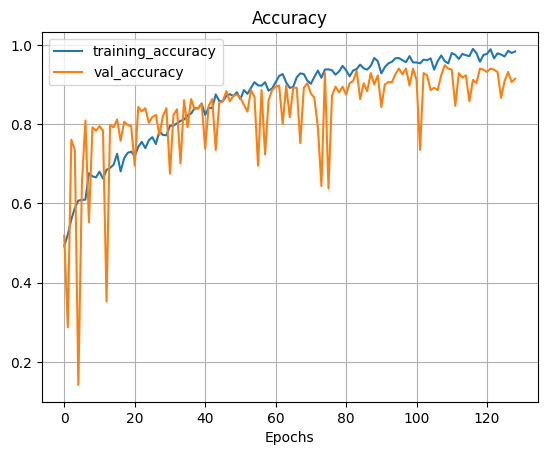

In [ ]:
def plot_loss_curves(history):
  """
  Returns separate loss curves for training and validation metrics.
  Args:
    history: TensorFlow model History object (see: https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/History)
  """
  loss = history.history['loss']
  val_loss = history.history['val_loss']

  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(len(history.history['loss']))

  # Plot loss
#   plt.plot(epochs, loss, label='training_loss')
#   plt.plot(epochs, val_loss, label='val_loss')
#   plt.title('Loss')
#   plt.xlabel('Epochs')
#   plt.legend()
#   plt.grid()


  # Plot accuracy
  plt.figure()
  plt.grid()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend();

plot_loss_curves(history)

## Results

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step


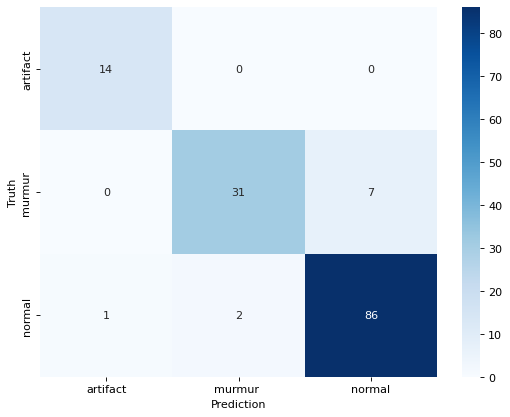

In [ ]:

classes = ["artifact" ,"murmur ", "normal"]

preds = lstm_model.predict(x_test_lstm)
classpreds = [ np.argmax(t) for t in preds ]
y_testclass = [np.argmax(t) for t in y_test_lstm]
cm = confusion_matrix(y_testclass, classpreds)

plt.figure(figsize=(8, 6), dpi=80, facecolor='w', edgecolor='k')
ax = sns.heatmap(cm, cmap='Blues', annot=True, fmt='d', xticklabels=classes, yticklabels=classes)

plt.title('')
plt.xlabel('Prediction')
plt.ylabel('Truth')
plt.show(ax)

In [ ]:
print(classification_report(y_testclass, classpreds, target_names=classes))

              precision    recall  f1-score   support

    artifact       0.93      1.00      0.97        14
     murmur        0.94      0.82      0.87        38
      normal       0.92      0.97      0.95        89

    accuracy                           0.93       141
   macro avg       0.93      0.93      0.93       141
weighted avg       0.93      0.93      0.93       141



## Prediction

In [ ]:
def heart_prediction(file_path, duration=10, sr=22050):
    classes = ["artifact", "murmur", "normal"]
    input_length = sr * duration

    # Load audio
    X, sr = librosa.load(file_path, sr=sr, duration=duration)
    dur = librosa.get_duration(y=X, sr=sr)

    # Fix length (new librosa API)
    if round(dur) < duration:
        X = librosa.util.fix_length(data=X, size=input_length)

    # Extract MFCC
    mfccs = np.mean(
        librosa.feature.mfcc(
            y=X,
            sr=sr,
            n_mfcc=52,
            n_fft=512,
            hop_length=2048
        ).T,
        axis=0
    )

    mfcc_input = mfccs.reshape(1, 52, 1)

    # Predict
    raw_pred = lstm_model.predict(mfcc_input)

    pred_class = classes[np.argmax(raw_pred)]
    confidence = float(np.max(raw_pred))

    return pred_class, confidence


TEST

In [ ]:
file_path = normal_data + normal_files[0]  # Change to a valid existing file path, e.g., using a file from the loaded dataset
pred, conf = heart_prediction(file_path)
print("Prediction:", pred)
print("Confidence:", conf)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
Prediction: normal
Confidence: 0.9831786155700684


In [ ]:
lstm_model.save("lstm_model.keras")

print("✅ Model saved successfully as lstm_model.keras")


✅ Model saved successfully as lstm_model.keras


In [ ]:
# Save the trained model in HDF5 (.h5) format
lstm_model.save("lstm_model.h5")

print("✅ Model saved successfully as lstm_model.h5")


✅ Model saved successfully as lstm_model.h5
